Saving Torgya - Arunachal Festival.jpg to Torgya - Arunachal Festival.jpg


(np.float64(-0.5), np.float64(2047.5), np.float64(1151.5), np.float64(-0.5))

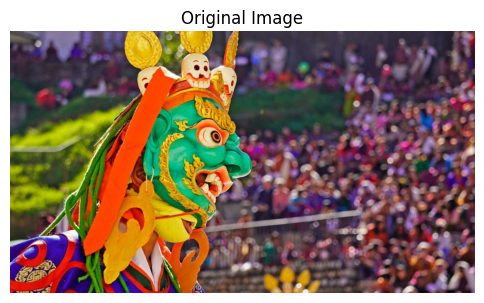

In [ ]:
# ---------------------------------------------
# IMPORT LIBRARIES
# ---------------------------------------------
import cv2
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt

# ---------------------------------------------
# UPLOAD THE IMAGE
# ---------------------------------------------
uploaded = files.upload()
img_name = list(uploaded.keys())[0]

# Read the image (color)
img = cv2.imread(img_name)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')


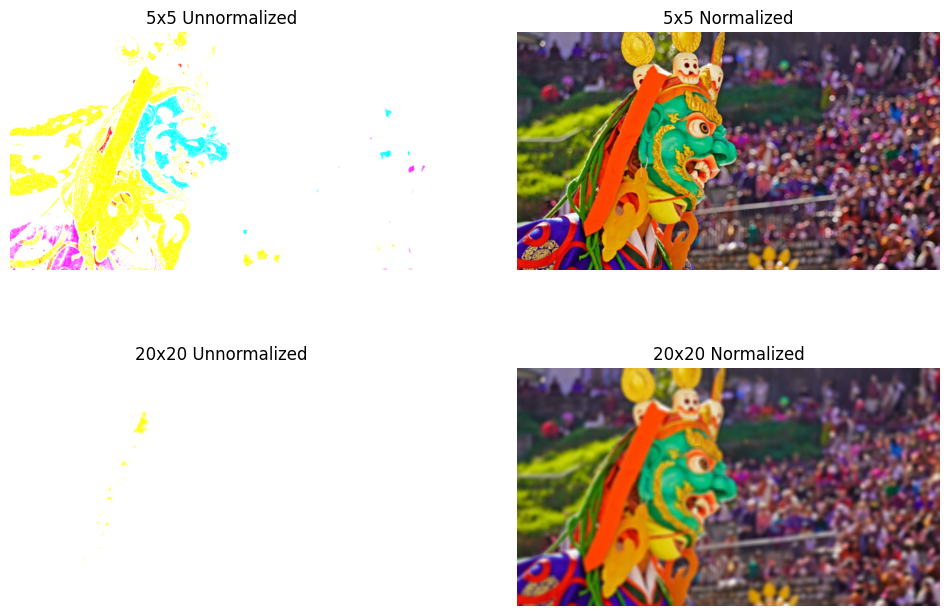

In [ ]:
def box_filter(img, k, normalize=True):
    kernel = np.ones((k, k), dtype=np.float32)

    if normalize:
        kernel = kernel / (k * k)  # mean filter

    return cv2.filter2D(img, -1, kernel)

# 5×5 unnormalized
box5_un = box_filter(img, 5, normalize=False)

# 5×5 normalized
box5_norm = box_filter(img, 5, normalize=True)

# 20×20 unnormalized
box20_un = box_filter(img, 20, normalize=False)

# 20×20 normalized
box20_norm = box_filter(img, 20, normalize=True)

# Display
titles = ["5x5 Unnormalized", "5x5 Normalized", "20x20 Unnormalized", "20x20 Normalized"]
images = [box5_un, box5_norm, box20_un, box20_norm]

plt.figure(figsize=(12,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')
plt.show()


In [ ]:
# ---------------------------------------------
# CHOOSE SIGMA
# ---------------------------------------------
sigma = 3.0  # you can modify

# Compute kernel size
k = int(6 * sigma + 1)
print("Sigma =", sigma)
print("Gaussian Kernel Size =", k)


Sigma = 3.0
Gaussian Kernel Size = 19


In [ ]:
# ---------------------------------------------
# CREATE 1D GAUSSIAN KERNEL (SEPARABLE)
# ---------------------------------------------
def gaussian_kernel_1d(k, sigma, normalize=True):
    half = k // 2
    x = np.arange(-half, half+1)
    kernel = np.exp(-(x**2) / (2*sigma**2))

    if normalize:
        kernel = kernel / np.sum(kernel)

    return kernel.reshape(-1,1)  # column vector

g_norm = gaussian_kernel_1d(k, sigma, normalize=True)
g_un = gaussian_kernel_1d(k, sigma, normalize=False)

print("Normalized Gaussian Kernel sum =", np.sum(g_norm))
print("Unnormalized Gaussian Kernel sum =", np.sum(g_un))


Normalized Gaussian Kernel sum = 0.9999999999999999
Unnormalized Gaussian Kernel sum = 7.508860679993253


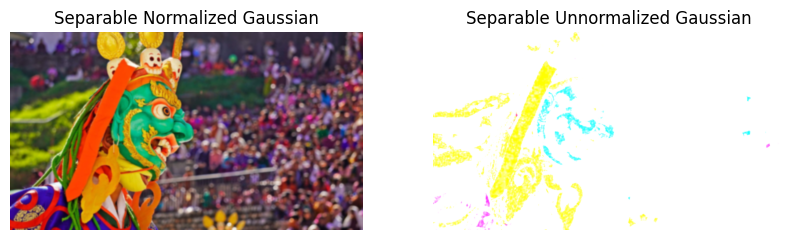

In [ ]:
# ---------------------------------------------
# APPLY SEPARABLE GAUSSIAN FILTERING
# ---------------------------------------------
def separable_gaussian(img, g1):
    # Horizontal pass
    temp = cv2.filter2D(img, -1, g1.T)
    # Vertical pass
    final = cv2.filter2D(temp, -1, g1)
    return final

gaussian_norm = separable_gaussian(img, g_norm)
gaussian_un = separable_gaussian(img, g_un)

# Display
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(gaussian_norm)
plt.title("Separable Normalized Gaussian")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(gaussian_un)
plt.title("Separable Unnormalized Gaussian")
plt.axis('off')
plt.show()
